In [1]:
import time
notebook_start = time.perf_counter()

# %pip install -e /home/darshan/A6/PCSAFT_cDFT/thermoift

import os
import pandas as pd
import numpy as np
import feos
import si_units as si
import matplotlib.pyplot as plt
import thermoift.FeosPlugin as TC
import thermoift.semi_emperical_correlations as SEC
import thermoift.PLOT_SETTINGS as ps

In [2]:
COMPONENT_NAMES = ["carbon dioxide", "hydrogen", "argon"]
FEED_Z          = np.array([0.95, 0.02, 0.03], dtype=float)
FEED_Z          = FEED_Z / FEED_Z.sum()

In [3]:
params          = TC.PARAMETERS(COMPONENT_NAMES)
eos             = feos.HelmholtzEnergyFunctional.pcsaft(params)
feed_si         = FEED_Z * si.MOL
Tc_si, Pc_si    = TC.VLECalculator.compute_critical_point(eos, FEED_Z, T_guess=300.0)
Tc_K            = Tc_si / si.KELVIN
Pc_bar          = Pc_si / si.BAR
T_vals          = np.linspace(200.0, Tc_K , 500)
T_bub, P_bub    = TC.VLECalculator.compute_bubble_curve(eos, T_vals, feed_si, verbose=False)
T_dew, P_dew    = TC.VLECalculator.compute_dew_curve(eos, T_vals, feed_si, verbose=False)

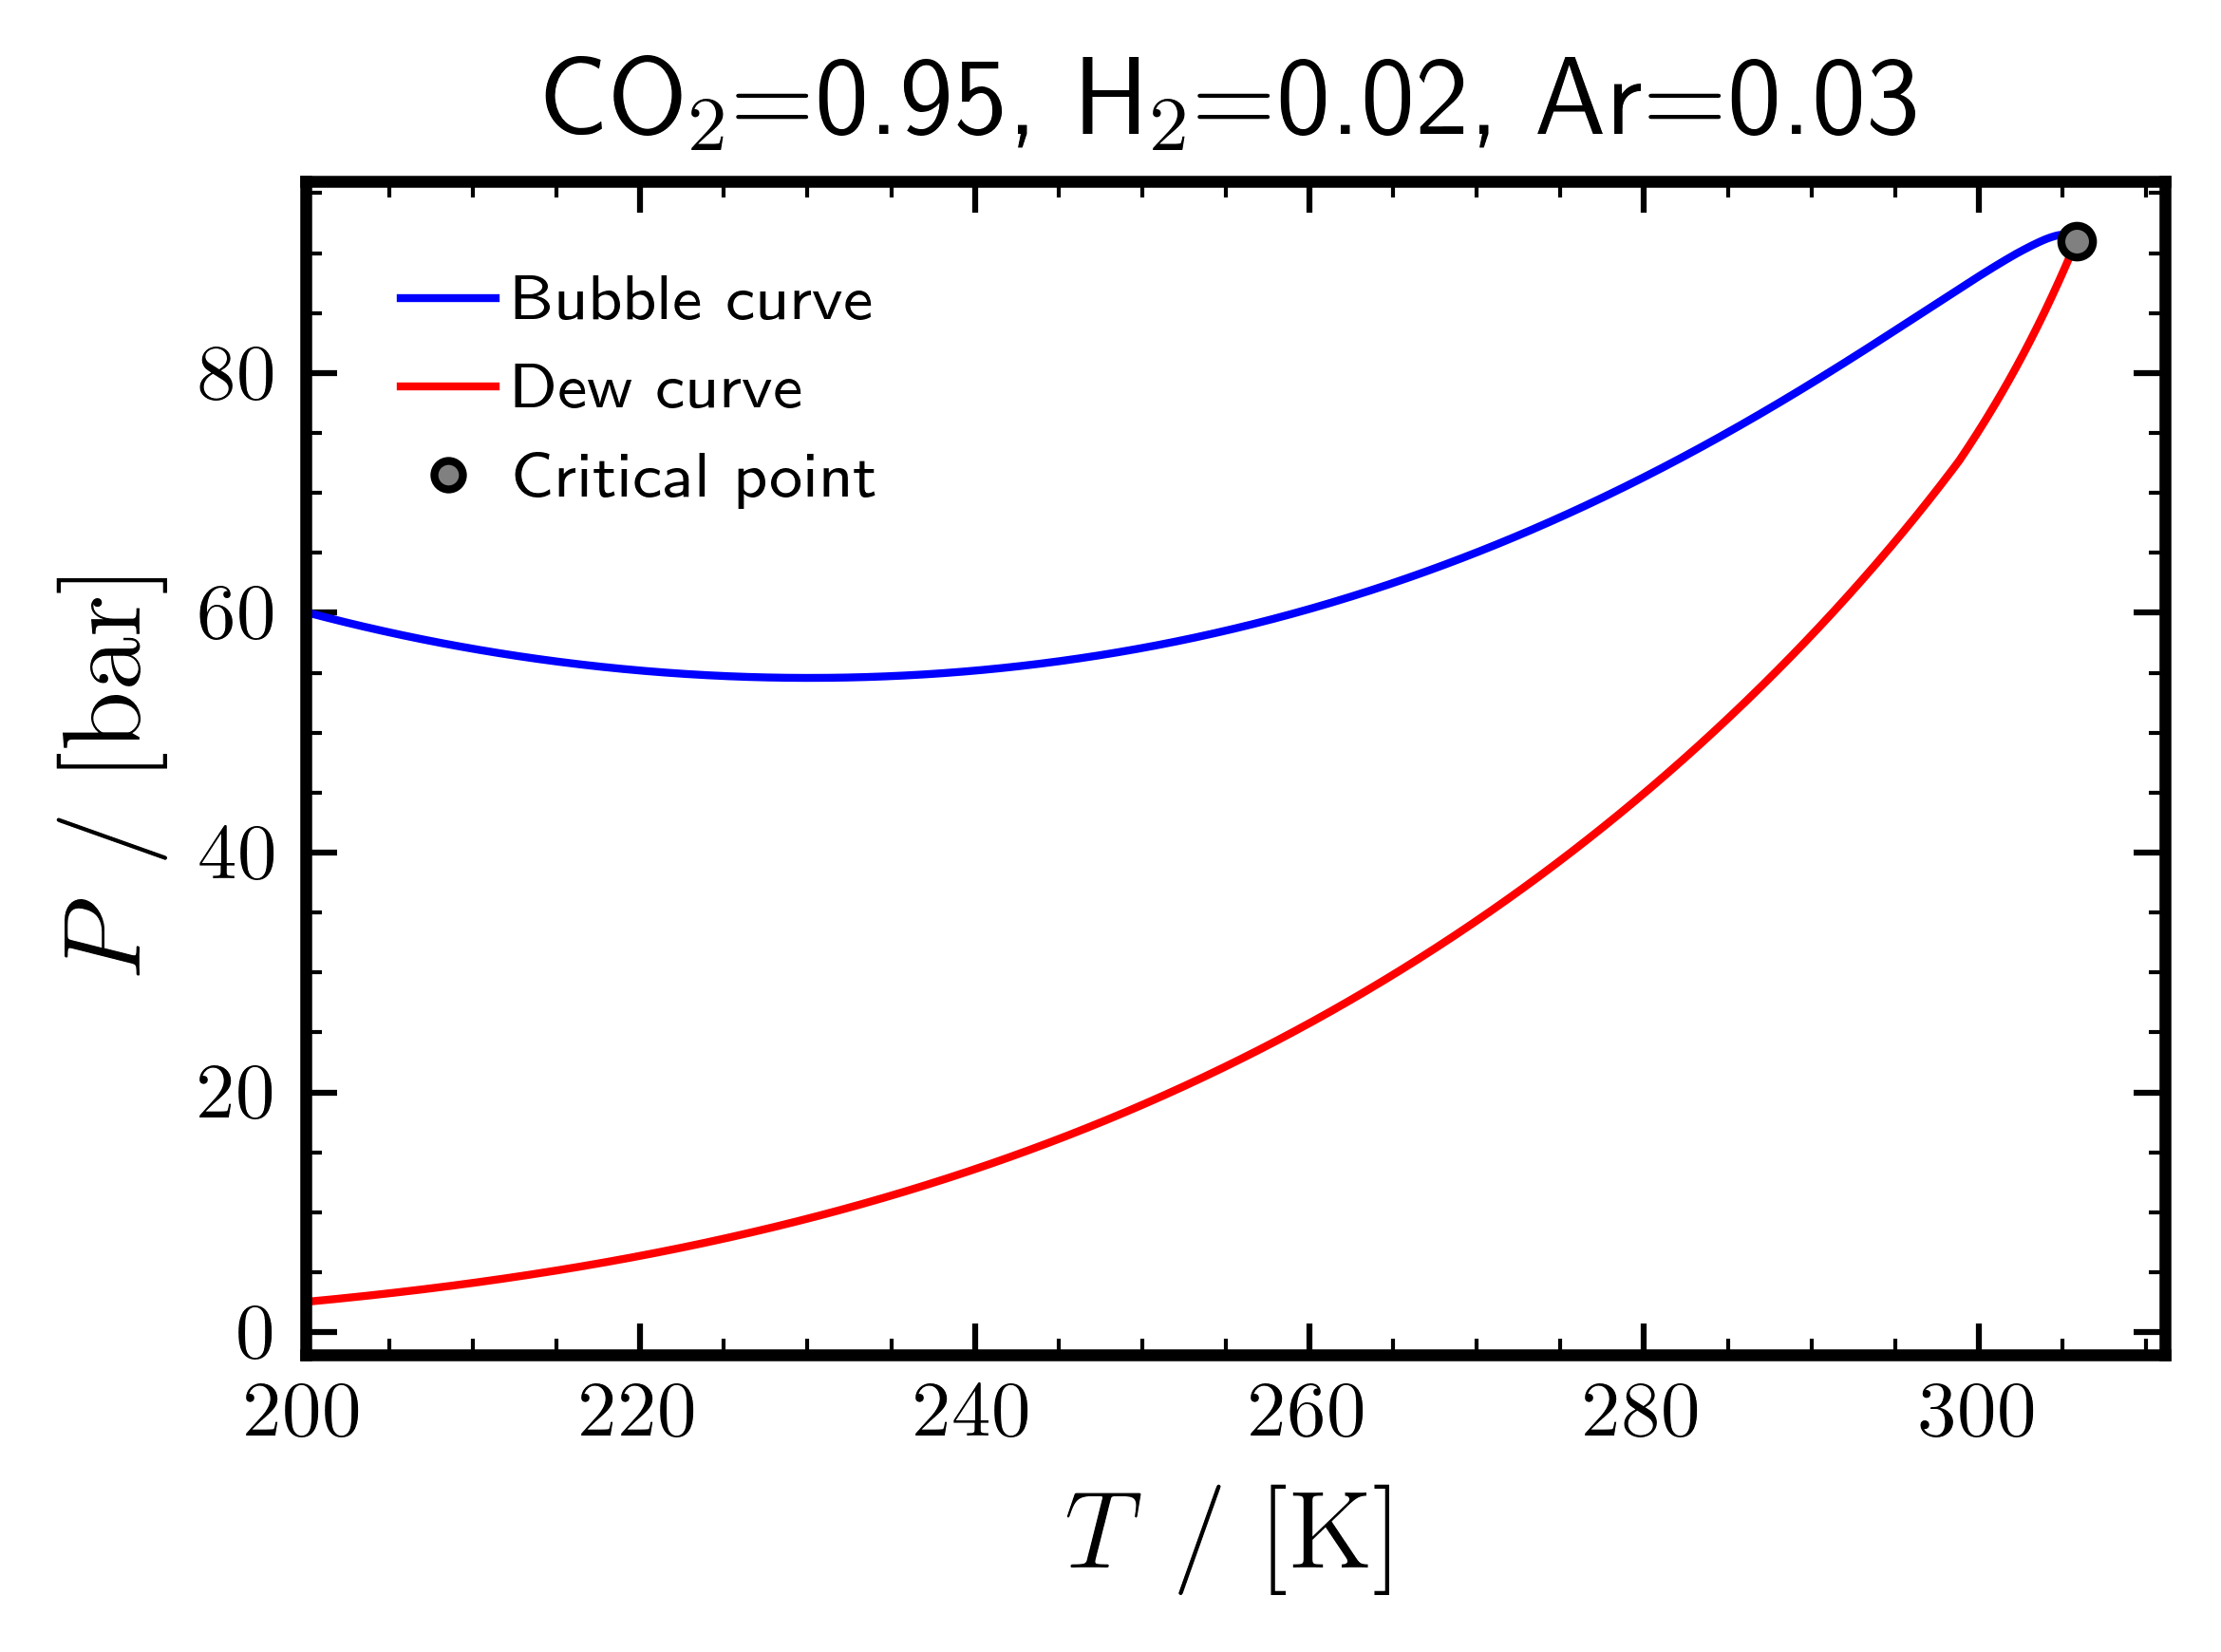

In [4]:
# Build PT_results dict in the format expected by PlottingEngine
feed_key = "feed_0"
PT_results = {
    feed_key: {
        "bubble": [{"T_K": T, "P_bar": P} for T, P in zip(T_bub, P_bub)],
        "dew": [{"T_K": T, "P_bar": P} for T, P in zip(T_dew, P_dew)],
        "TC_K": Tc_K,
        "PC_bar": Pc_bar,
        "z": FEED_Z,
    }
}

# Plot using PlottingEngine
fig, ax = TC.PlottingEngine.plot_phase_diagram(PT_results, feed_key, params)
plt.show()

In [5]:
# -------------------------------------------------------------------------------------------
# Compute IFT along saturation lines only (bubble & dew curves) - for metastable computations
# -------------------------------------------------------------------------------------------

# Compute IFT only at bubble and dew points Parachor method (T-dependent)
model = SEC.semi_emperical_correlations()

N_POINTS = 50  # Use 50(fast)/500(slow)

sat_data_parachor = model.compute_saturation_line_IFT(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="parachor",
    n_exp=3.87,
    kij_parachor=0.0,
    recompute_parachor=True,
    line="both",
    n_points=N_POINTS,        # Use coarser T grid for speed
    P_offset_frac=0.005,      # 0.5% offset to stay inside two-phase region
)

# WSD method with correction along saturation lines
sat_data_wsd_corr = model.compute_saturation_line_IFT(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="wsd",
    phi_wsd=1.0,
    wsd_correction=True,
    line="both",
    n_points=N_POINTS,
    P_offset_frac=0.005,
)

# WSD method without correction along saturation lines
sat_data_wsd_no_corr = model.compute_saturation_line_IFT(
    component_names=COMPONENT_NAMES,
    feed_z=FEED_Z,
    eos=eos,
    T_bub=T_bub,
    P_bub=P_bub,
    T_dew=T_dew,
    P_dew=P_dew,
    method="wsd",
    phi_wsd=1.0,
    wsd_correction=False,
    line="both",
    n_points=N_POINTS,
    P_offset_frac=0.005,
)

# Convert to DataFrames
df_sat_parachor = SEC.semi_emperical_correlations.saturation_line_to_dataframe(
    sat_data_parachor, COMPONENT_NAMES, line="both")

df_sat_wsd_corr = SEC.semi_emperical_correlations.saturation_line_to_dataframe(
    sat_data_wsd_corr, COMPONENT_NAMES, line="both")

df_sat_wsd_no_corr = SEC.semi_emperical_correlations.saturation_line_to_dataframe(
    sat_data_wsd_no_corr, COMPONENT_NAMES, line="both")

print(f"Parachor DataFrame shape: {df_sat_parachor.shape}")
print(f"WSD (with correction) DataFrame shape: {df_sat_wsd_corr.shape}")
print(f"WSD (no correction) DataFrame shape: {df_sat_wsd_no_corr.shape}")

/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:177: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=300.61397145980027 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:177: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=302.7546942568173 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:177: UserWarning: cDFT solve failed for pure component 'carbon dioxide (From semi_emperical_correlations)' at T=304.8954170538343 K: `DFT` did not converge within the maximum number of iterations.
  warnings.warn(
/home/darshan/A6/PCSAFT_cDFT/thermoift/src/thermoift/semi_emperical_correlations.py:177: UserWarning: cDF

Parachor DataFrame shape: (100, 33)
WSD (with correction) DataFrame shape: (96, 33)
WSD (no correction) DataFrame shape: (96, 33)


In [6]:
# -------------------------------------------------------------------------------------------
# Save phase envelope and IFT results to two CSV files (bubble and dew)
# -------------------------------------------------------------------------------------------
os.makedirs("CSV_saturation", exist_ok=True)

# Extract bubble line data from each method
bub_parachor = df_sat_parachor[df_sat_parachor["line"] == "bubble"][["T", "P", "gamma_mix"]].copy()
bub_wsd_no_corr = df_sat_wsd_no_corr[df_sat_wsd_no_corr["line"] == "bubble"][["T", "gamma_mix"]].copy()
bub_wsd_corr = df_sat_wsd_corr[df_sat_wsd_corr["line"] == "bubble"][["T", "gamma_mix"]].copy()

# Extract dew line data from each method
dew_parachor = df_sat_parachor[df_sat_parachor["line"] == "dew"][["T", "P", "gamma_mix"]].copy()
dew_wsd_no_corr = df_sat_wsd_no_corr[df_sat_wsd_no_corr["line"] == "dew"][["T", "gamma_mix"]].copy()
dew_wsd_corr = df_sat_wsd_corr[df_sat_wsd_corr["line"] == "dew"][["T", "gamma_mix"]].copy()

# Rename columns for bubble
bub_parachor.rename(columns={"P": "P_bubble", "gamma_mix": "gamma_parachor"}, inplace=True)
bub_wsd_no_corr.rename(columns={"gamma_mix": "gamma_WSD"}, inplace=True)
bub_wsd_corr.rename(columns={"gamma_mix": "gamma_WSD_correction"}, inplace=True)

# Rename columns for dew
dew_parachor.rename(columns={"P": "P_dew", "gamma_mix": "gamma_parachor"}, inplace=True)
dew_wsd_no_corr.rename(columns={"gamma_mix": "gamma_WSD"}, inplace=True)
dew_wsd_corr.rename(columns={"gamma_mix": "gamma_WSD_correction"}, inplace=True)

# Merge bubble data on temperature
df_bubble = bub_parachor.merge(bub_wsd_no_corr, on="T", how="outer")
df_bubble = df_bubble.merge(bub_wsd_corr, on="T", how="outer")
df_bubble = df_bubble[["T", "P_bubble", "gamma_parachor", "gamma_WSD", "gamma_WSD_correction"]]
df_bubble = df_bubble.sort_values("T").reset_index(drop=True)

# Merge dew data on temperature
df_dew = dew_parachor.merge(dew_wsd_no_corr, on="T", how="outer")
df_dew = df_dew.merge(dew_wsd_corr, on="T", how="outer")
df_dew = df_dew[["T", "P_dew", "gamma_parachor", "gamma_WSD", "gamma_WSD_correction"]]
df_dew = df_dew.sort_values("T").reset_index(drop=True)

# Save bubble CSV
bubble_csv = "CSV_saturation/bubble_IFT.csv"
df_bubble.to_csv(bubble_csv, index=False)
print(f"Bubble CSV saved to {bubble_csv} ({len(df_bubble)} rows)")
print(df_bubble.head())

# Save dew CSV
dew_csv = "CSV_saturation/dew_IFT.csv"
df_dew.to_csv(dew_csv, index=False)
print(f"\nDew CSV saved to {dew_csv} ({len(df_dew)} rows)")
print(df_dew.head())

Bubble CSV saved to CSV_saturation/bubble_IFT.csv (50 rows)
            T   P_bubble  gamma_parachor  gamma_WSD  gamma_WSD_correction
0  200.000000  60.061593       14.676296  18.129779             17.225749
1  202.140723  59.296638       14.354296  17.653863             16.773603
2  204.281446  58.592744       14.027010  17.180375             16.323765
3  206.422168  57.948390       13.695008  16.709366             15.876281
4  208.562891  57.362318       13.358819  16.240887             15.431201

Dew CSV saved to CSV_saturation/dew_IFT.csv (50 rows)
            T     P_dew  gamma_parachor  gamma_WSD  gamma_WSD_correction
0  200.000000  2.523373       19.889885  19.898993             19.892300
1  202.010997  2.795424       19.413255  19.423195             19.416004
2  204.021993  3.089672       18.938675  18.949495             18.941789
3  206.032990  3.407436       18.466166  18.477921             18.469680
4  208.043987  3.749839       17.995782  18.008524             17.999730


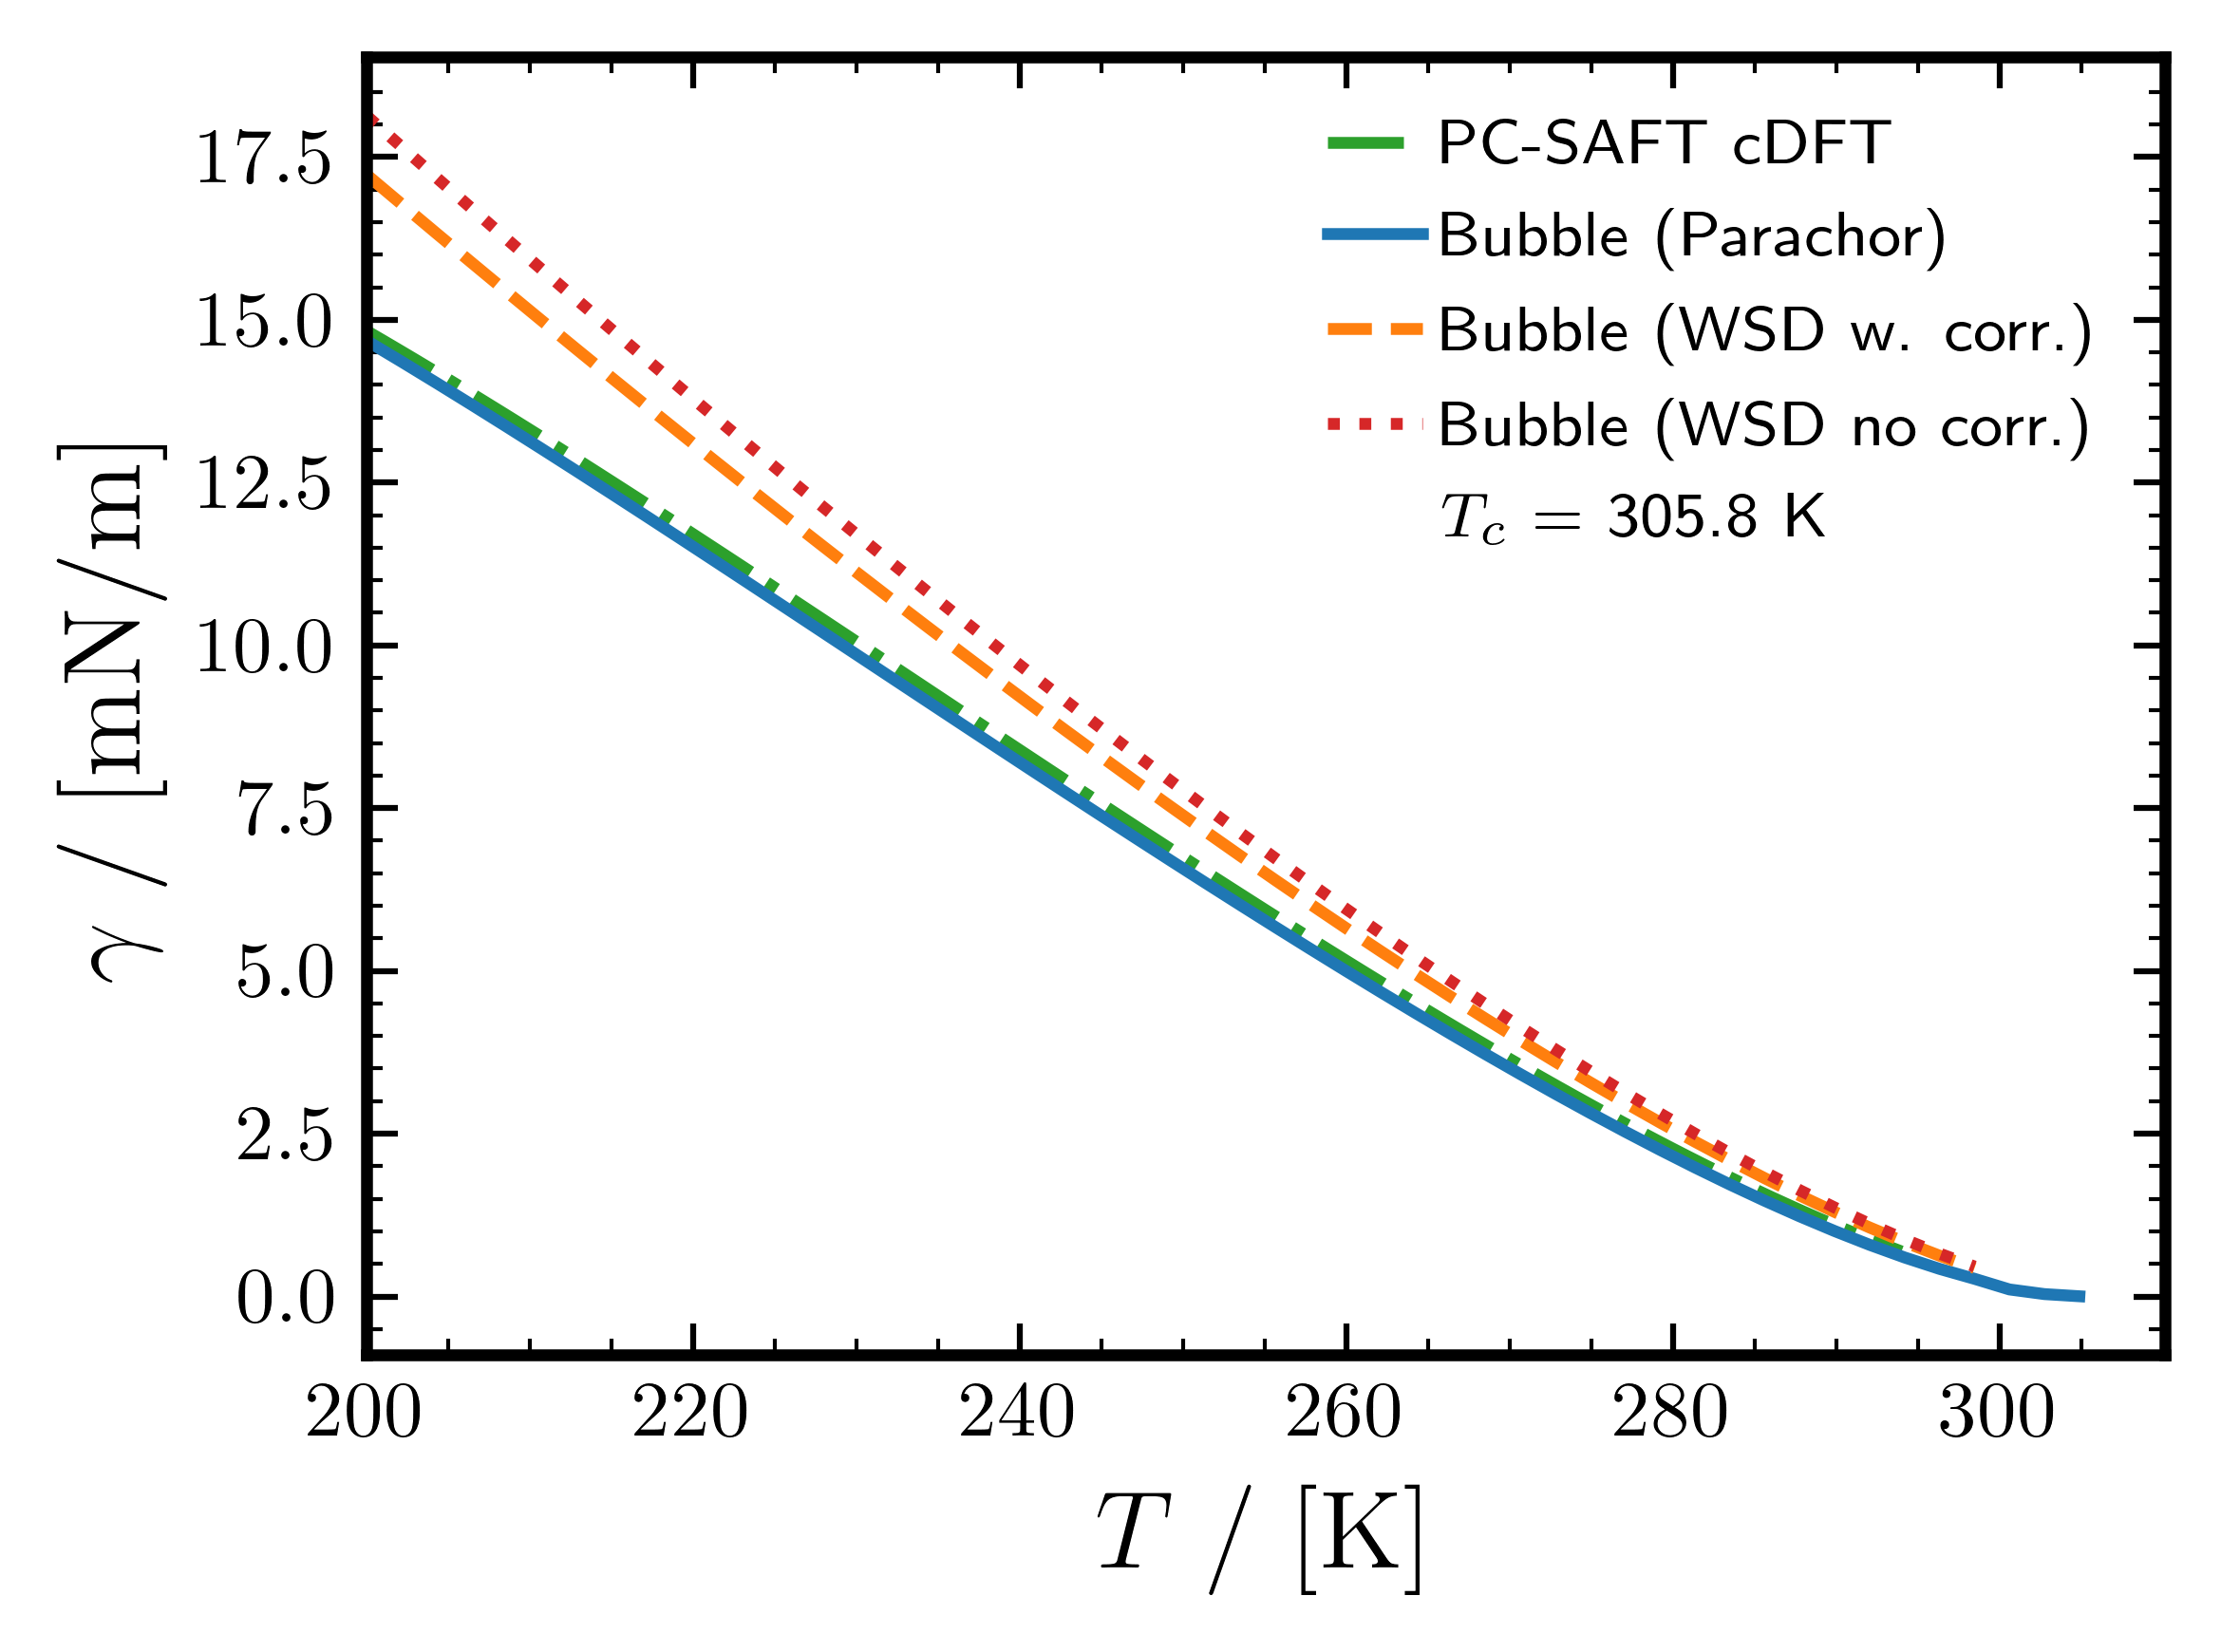

Bubble IFT plot saved to CSV/bubble_IFT_vs_T.png and CSV/bubble_IFT_vs_T.pdf


In [7]:
# --- Bubble IFT vs Temperature ---

fig, ax = ps.plot_init()

df_pcsaft = (pd.read_csv("CSV/feed_1_bubble_point_IFT.csv",usecols=["temperature", "gamma"]).dropna(subset=["gamma"]))

# PC-SAFT cDFT
if not df_pcsaft.empty:
    ax.plot(df_pcsaft["temperature"],df_pcsaft["gamma"],label="PC-SAFT cDFT", linestyle="-.", color="C2")

if df_sat_parachor.empty and df_sat_wsd_corr.empty and df_sat_wsd_no_corr.empty:
    print("No data available - all DataFrames are empty")
else:
    # Parachor
    if not df_sat_parachor.empty and "line" in df_sat_parachor.columns:
        bub_para = df_sat_parachor[df_sat_parachor["line"] == "bubble"]

        if not bub_para.empty:
            ax.plot(
                bub_para["T"],
                bub_para["gamma_mix"],
                "-",
                label="Bubble (Parachor)",
                color="C0")

    # WSD with correction
    if not df_sat_wsd_corr.empty and "line" in df_sat_wsd_corr.columns:
        bub_wsd_corr = df_sat_wsd_corr[df_sat_wsd_corr["line"] == "bubble"]

        if not bub_wsd_corr.empty:
            ax.plot(
                bub_wsd_corr["T"],
                bub_wsd_corr["gamma_mix"],
                "--",
                label="Bubble (WSD w. corr.)",
                color="C1")

    # WSD without correction
    if not df_sat_wsd_no_corr.empty and "line" in df_sat_wsd_no_corr.columns:
        bub_wsd_no_corr = df_sat_wsd_no_corr[df_sat_wsd_no_corr["line"] == "bubble"]

        if not bub_wsd_no_corr.empty:
            ax.plot(
                bub_wsd_no_corr["T"],
                bub_wsd_no_corr["gamma_mix"],
                ":",
                label="Bubble (WSD no corr.)",
                color="C3")

ax.axvline(Tc_K, color="w", linestyle=":", label=f"$T_c$ = {Tc_K:.1f} K")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
ax.set_xlim(left=200)
ax.minorticks_on()
ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
plt.tight_layout()
plt.savefig("CSV/bubble_IFT_vs_T.png", dpi=300, bbox_inches="tight")
plt.savefig("CSV/bubble_IFT_vs_T.pdf", bbox_inches="tight")
plt.show()
print("Bubble IFT plot saved to CSV/bubble_IFT_vs_T.png and CSV/bubble_IFT_vs_T.pdf")

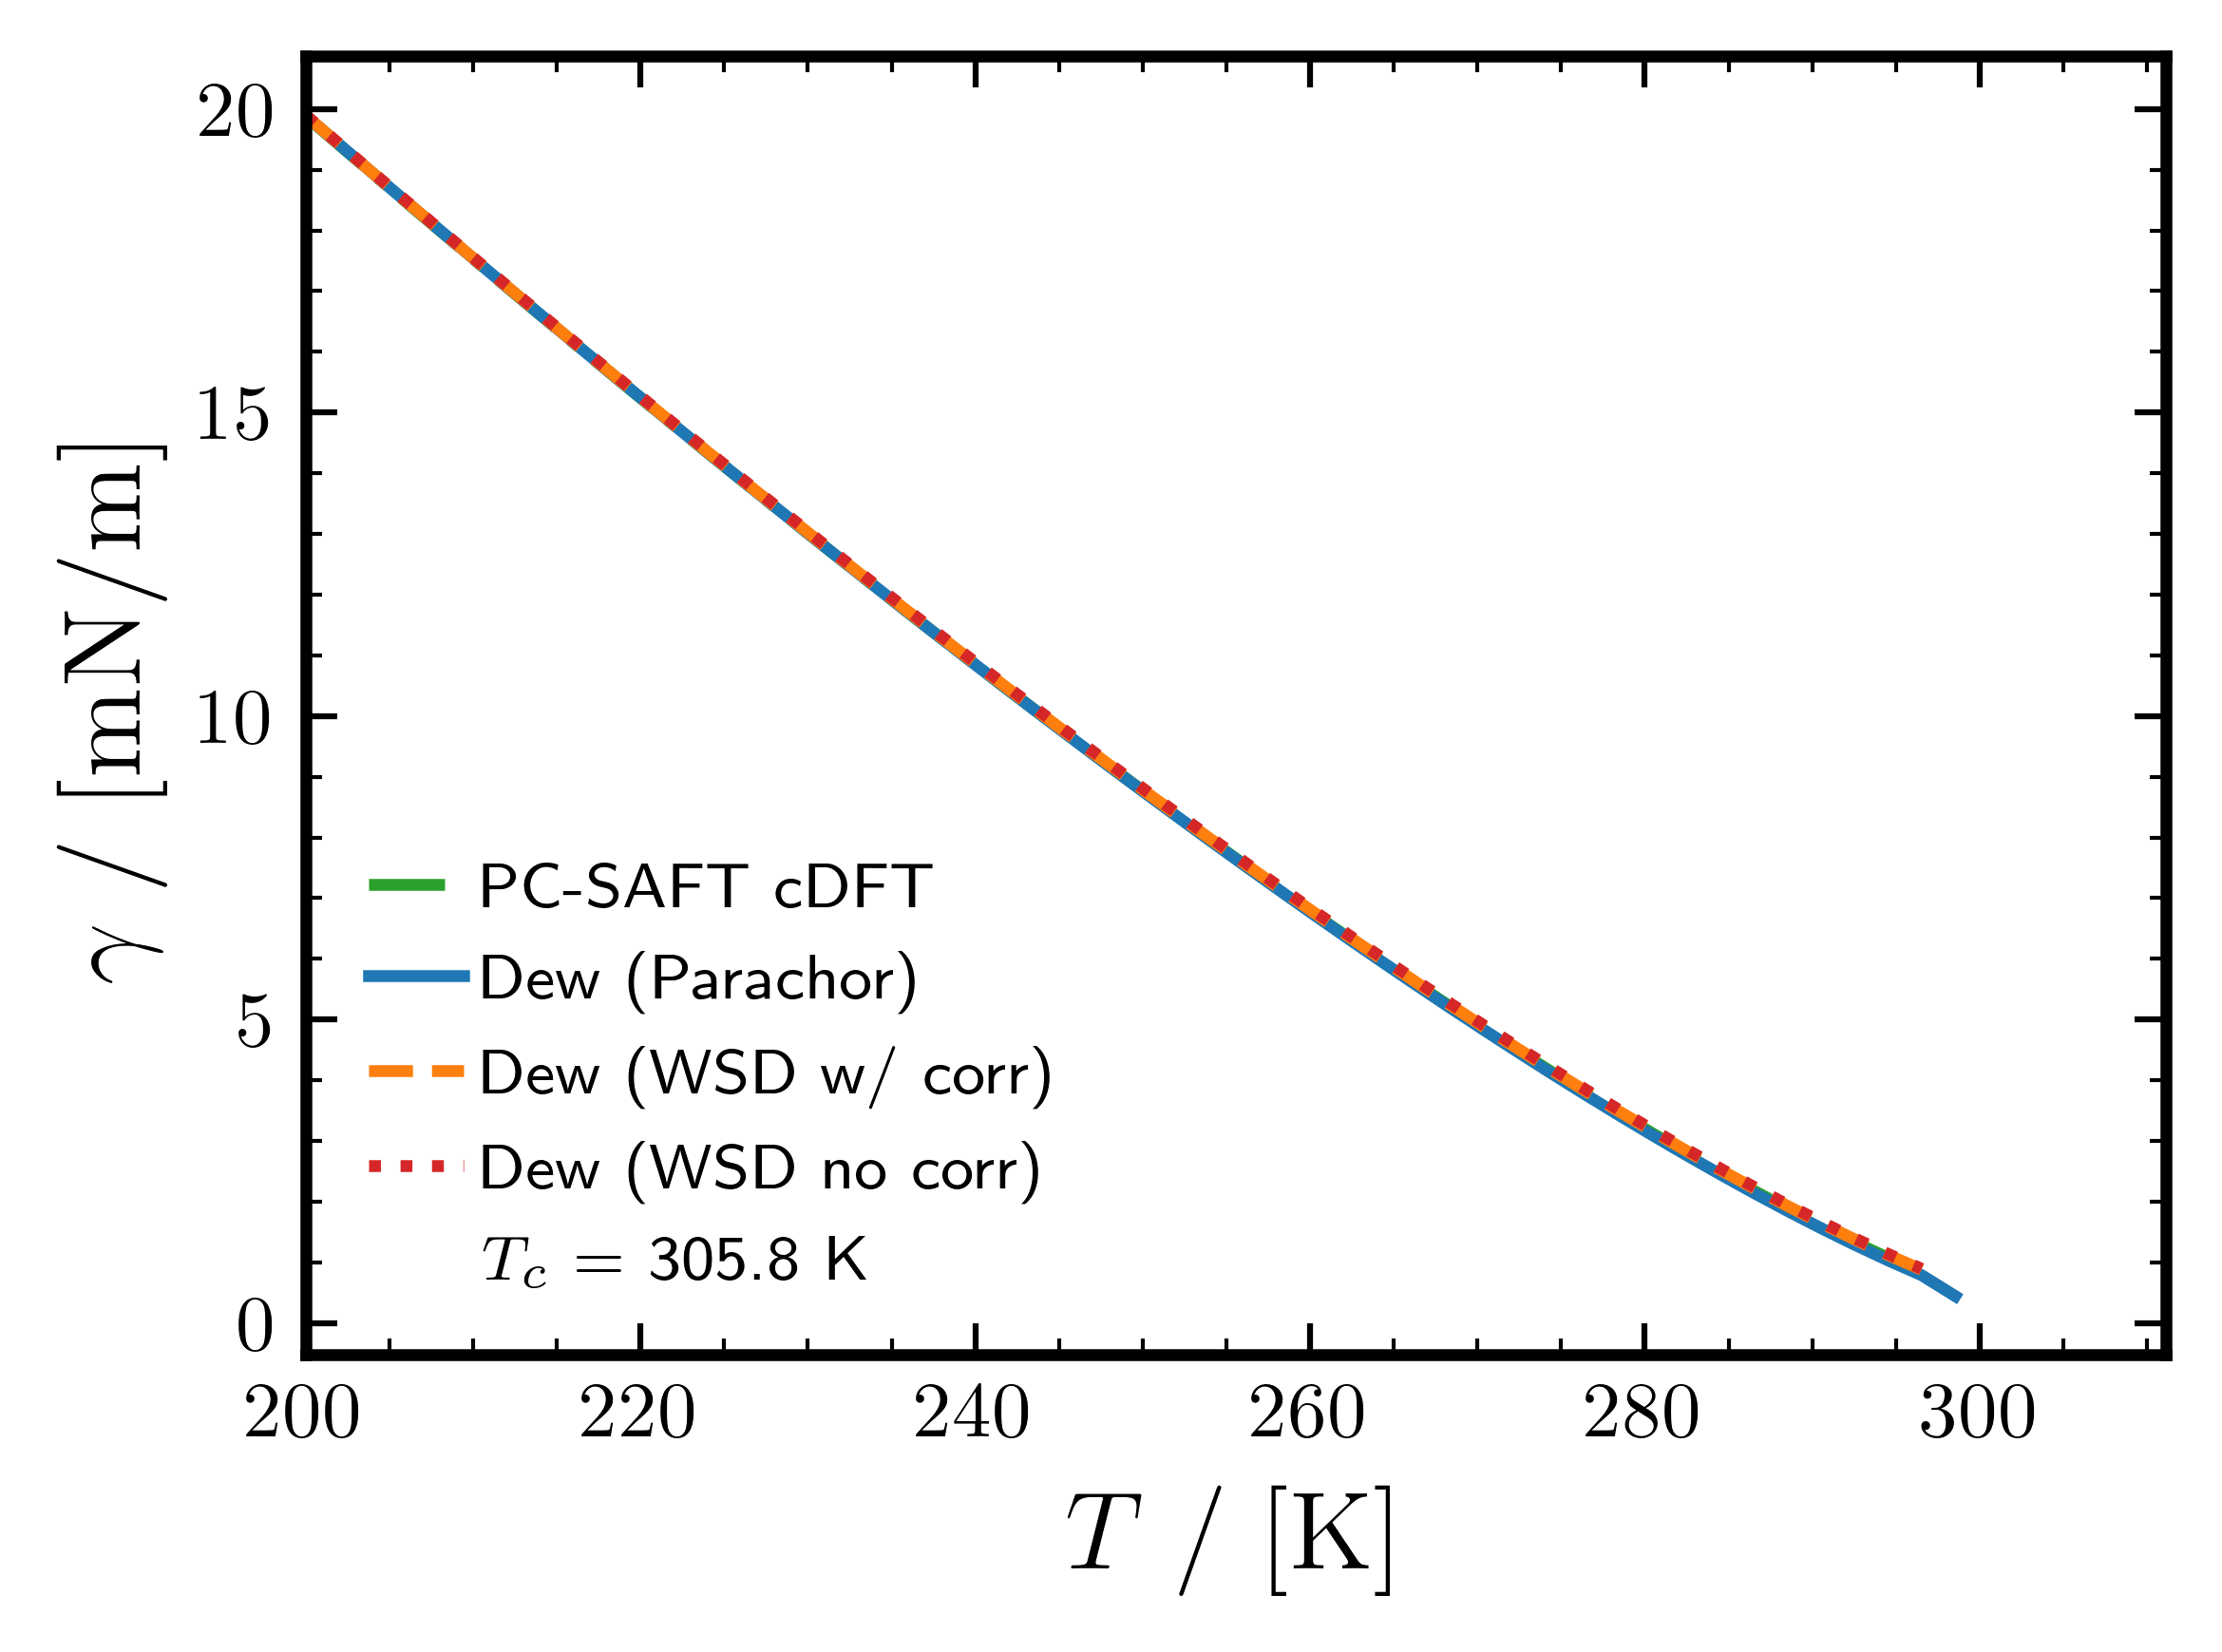

Dew IFT plot saved to CSV/dew_IFT_vs_T.png and CSV/dew_IFT_vs_T.pdf


In [8]:
# --- Dew IFT vs Temperature ---

fig, ax = ps.plot_init()

df_pcsaft_dew = (pd.read_csv("CSV/feed_1_dew_point_IFT.csv",usecols=["temperature", "gamma"]).dropna(subset=["temperature", "gamma"]))

# PC-SAFT cDFT
if not df_pcsaft_dew.empty:
    ax.plot(df_pcsaft_dew["temperature"],df_pcsaft_dew["gamma"],label="PC-SAFT cDFT",linestyle="-.",color="C2")

if df_sat_parachor.empty and df_sat_wsd_corr.empty and df_sat_wsd_no_corr.empty:
    print("No data available - all DataFrames are empty")
else:
    # Parachor
    if not df_sat_parachor.empty and "line" in df_sat_parachor.columns:
        dew_para = df_sat_parachor[df_sat_parachor["line"] == "dew"]

        if not dew_para.empty:
            ax.plot(
                dew_para["T"],
                dew_para["gamma_mix"],
                "-",
                label="Dew (Parachor)",
                color="C0"
            )

    # WSD with correction
    if not df_sat_wsd_corr.empty and "line" in df_sat_wsd_corr.columns:
        dew_wsd_corr = df_sat_wsd_corr[df_sat_wsd_corr["line"] == "dew"]

        if not dew_wsd_corr.empty:
            ax.plot(
                dew_wsd_corr["T"],
                dew_wsd_corr["gamma_mix"],
                "--",
                label="Dew (WSD w/ corr)",
                color="C1"
            )

    # WSD without correction
    if not df_sat_wsd_no_corr.empty and "line" in df_sat_wsd_no_corr.columns:
        dew_wsd_no_corr = df_sat_wsd_no_corr[df_sat_wsd_no_corr["line"] == "dew"]

        if not dew_wsd_no_corr.empty:
            ax.plot(
                dew_wsd_no_corr["T"],
                dew_wsd_no_corr["gamma_mix"],
                ":",
                label="Dew (WSD no corr)",
                color="C3"
            )

ax.axvline(Tc_K, color="w", linestyle=":", label=f"$T_c$ = {Tc_K:.1f} K")
ax.set_xlabel(r"$T \; / \; [\mathrm{K}]$", fontsize=ps.label_fontsize)
ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
ax.set_xlim(left=200)
ax.minorticks_on()
ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
plt.tight_layout()
plt.savefig("CSV/dew_IFT_vs_T.png", dpi=300, bbox_inches="tight")
plt.savefig("CSV/dew_IFT_vs_T.pdf", bbox_inches="tight")
plt.show()
print("Dew IFT plot saved to CSV/dew_IFT_vs_T.png and CSV/dew_IFT_vs_T.pdf")

In [9]:
# # --- Plot 2: IFT vs Pressure ---
# if df_sat_parachor.empty and df_sat_wsd.empty:
#     print("No data available - both DataFrames are empty")
# else:
#     fig, ax = ps.plot_init()

#     if bub_para is not None and not bub_para.empty:
#         ax.plot(
#             bub_para["P"], bub_para["gamma_mix"],
#             "-", label="Bubble (Parachor)", color="C0")

#     if bub_wsd is not None and not bub_wsd.empty:
#         ax.plot(
#             bub_wsd["P"], bub_wsd["gamma_mix"],
#             "-", label="Bubble (WSD)", color="C1")

#     ax.axvline(Pc_bar, color="w", linestyle=":", label=f"$P_c$ = {Pc_bar:.1f} bar")
#     ax.set_xlabel(r"$P \; / \; [\mathrm{bar}]$", fontsize=ps.label_fontsize)
#     ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
#     ax.minorticks_on()
#     ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
#     plt.tight_layout()
#     plt.show()

In [10]:
# # --- Plot 2: IFT vs Pressure ---
# if df_sat_parachor.empty and df_sat_wsd.empty:
#     print("No data available - both DataFrames are empty")
# else:
#     fig, ax = ps.plot_init()

#     if bub_para is not None and not bub_para.empty:
#         ax.plot(
#             bub_para["P"], bub_para["gamma_mix"],
#             "-", label="Bubble (Parachor)", color="C0")

#     if dew_para is not None and not dew_para.empty:
#         ax.plot(
#             dew_para["P"], dew_para["gamma_mix"],
#             "--", label="Dew (Parachor)", color="C0", alpha=0.7)

#     if bub_wsd is not None and not bub_wsd.empty:
#         ax.plot(
#             bub_wsd["P"], bub_wsd["gamma_mix"],
#             "-", label="Bubble (WSD)", color="C1")

#     if dew_wsd is not None and not dew_wsd.empty:
#         ax.plot(
#             dew_wsd["P"], dew_wsd["gamma_mix"],
#             "--", label="Dew (WSD)", color="C1", alpha=0.7)

#     ax.axvline(Pc_bar, color="w", linestyle=":", label=f"$P_c$ = {Pc_bar:.1f} bar")
#     ax.set_xlabel(r"$P \; / \; [\mathrm{bar}]$", fontsize=ps.label_fontsize)
#     ax.set_ylabel(r"$\gamma \; / \; [\mathrm{mN/m}]$", fontsize=ps.label_fontsize)
#     ax.minorticks_on()
#     ps.style_legend(ax, fontsize=ps.legend_fontsize, loc="best", framealpha=0)
#     plt.tight_layout()
#     plt.show()

In [11]:
notebook_end = time.perf_counter()
elapsed_minutes = (notebook_end - notebook_start) / 60
print(f"Total notebook runtime: {elapsed_minutes:.2f} minutes")

Total notebook runtime: 0.76 minutes
